### Troubleshooting notes for future reference
Identifies the location of the CA bundle used by the certifi package, used to verify SSL certificates in Python applications if error in SSL verification occurs.

```python
import certifi
certifi.where()
```

after locating the file location, run the following commands in terminal to update the CA bundle

```python
setx SSL_CERT_FILE "path\to\cacert.pem"
setx REQUESTS_CA_BUNDLE "path\to\cacert.pem"
```

In [1]:
import pandas as pd
from pystac_client import Client

In [2]:
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

In [3]:
from dask.distributed import LocalCluster

In [4]:
import odc.stac

In [ ]:
cluster = LocalCluster()  # Creates local cluster

2026-01-29 15:58:09,947 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x0000027680B03D70>, <Task finished name='Task-1460' coro=<BaseTCPListener._handle_stream() done, defined at c:\Users\Henry\Desktop\MUSA6500_Desktop\musa-6500-spring2026-repo\.venv_musa6500\Lib\site-packages\distributed\comm\tcp.py:655> exception=ValueError('invalid operation on non-started TCPListener')>)
Traceback (most recent call last):
  File "c:\Users\Henry\Desktop\MUSA6500_Desktop\musa-6500-spring2026-repo\.venv_musa6500\Lib\site-packages\tornado\ioloop.py", line 758, in _run_callback
    ret = callback()
  File "c:\Users\Henry\Desktop\MUSA6500_Desktop\musa-6500-spring2026-repo\.venv_musa6500\Lib\site-packages\tornado\tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ~~~~~~~~^^
  File "c:\Users\Henry\Desktop\MUSA6500_Desktop\musa-6500-spring20

In [ ]:
client = cluster.get_client()
cluster.adapt(minimum=4, maximum=20)
print(cluster.scheduler)
print(cluster.workers)

<Scheduler 'tcp://127.0.0.1:56479', workers: 6, cores: 24, tasks: 0>
{0: <Nanny: tcp://127.0.0.1:56526, threads: 4>, 1: <Nanny: tcp://127.0.0.1:56536, threads: 4>, 2: <Nanny: tcp://127.0.0.1:56522, threads: 4>, 3: <Nanny: tcp://127.0.0.1:56539, threads: 4>, 4: <Nanny: tcp://127.0.0.1:56523, threads: 4>, 5: <Nanny: tcp://127.0.0.1:56527, threads: 4>}


2026-01-29 15:58:13,947 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-01-29 15:58:13,952 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


In [7]:
odc.stac.configure_rio(cloud_defaults=True, client=client)

In [8]:
# check available landsat collections within the catalog
all_collections = [i.id for i in catalog.get_collections()]
landsat_collections = [
    collection for collection in all_collections if "landsat" in collection
]
landsat_collections

['landsat-c2-l2', 'landsat-c2-l1']

In [9]:
# identify bbox for singapore, date range, and collection
bbox = [103.577522,1.160000,104.107269,1.480106]
dates = "2025-01-01/2025-12-31"
collection = "landsat-c2-l2"
cloudylvl = 50

In [10]:
# create a search object with the parameters
search = catalog.search(
    collections=[collection],
    bbox=bbox,
    datetime=dates,
    query={"eo:cloud_cover": {"lt": cloudylvl}},
)

# view items from the search
items = search.item_collection()
print(f"Returned {len(items)} Items:")
item_id = {(i, item.id): i for i, item in enumerate(items)}
item_id

Returned 23 Items:


{(0, 'LC08_L2SP_125059_20251205_02_T1'): 0,
 (1, 'LC09_L2SP_125059_20251026_02_T1'): 1,
 (2, 'LC08_L2SP_125059_20251018_02_T1'): 2,
 (3, 'LC08_L2SP_125059_20251002_02_T1'): 3,
 (4, 'LC09_L2SP_125059_20250924_02_T1'): 4,
 (5, 'LC08_L2SP_125059_20250916_02_T2'): 5,
 (6, 'LC08_L2SP_125059_20250831_02_T1'): 6,
 (7, 'LC08_L2SP_125059_20250815_02_T1'): 7,
 (8, 'LC09_L2SP_125059_20250807_02_T1'): 8,
 (9, 'LC08_L2SP_125059_20250730_02_T1'): 9,
 (10, 'LC09_L2SP_125059_20250706_02_T1'): 10,
 (11, 'LC09_L2SP_125059_20250604_02_T1'): 11,
 (12, 'LC08_L2SP_125059_20250527_02_T1'): 12,
 (13, 'LC08_L2SP_125059_20250511_02_T1'): 13,
 (14, 'LC09_L2SP_125059_20250503_02_T1'): 14,
 (15, 'LC08_L2SP_125059_20250425_02_T1'): 15,
 (16, 'LC08_L2SP_125059_20250409_02_T1'): 16,
 (17, 'LC09_L2SP_125059_20250401_02_T1'): 17,
 (18, 'LC08_L2SP_125059_20250308_02_T1'): 18,
 (19, 'LC08_L2SP_125059_20250220_02_T1'): 19,
 (20, 'LC09_L2SP_125059_20250212_02_T1'): 20,
 (21, 'LC09_L2SP_125059_20250127_02_T2'): 21,
 (22, 'L

In [11]:
import geopandas as gpd

In [12]:
# load searched item information into a dataframe
# converts items to a method, then creates features from it
images = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")
images.head()

,geometry,gsd,created,sci:doi,datetime,platform,proj:shape,description,instruments,eo:cloud_cover,...,landsat:scene_id,landsat:wrs_path,landsat:wrs_type,view:sun_azimuth,landsat:correction,view:sun_elevation,landsat:cloud_cover_land,landsat:collection_number,landsat:collection_category,proj:code
0,"POLYGON ((103.49919 2.48791, 103.13098 0.75238...",30,2025-12-12T09:21:32.178349Z,10.5066/P9OGBGM6,2025-12-05T03:16:53.020717Z,landsat-8,"[7741, 7591]",Landsat Collection 2 Level-2,"[oli, tirs]",5.03,...,LC81250592025339LGN00,125,2,136.596302,L2SP,56.404027,10.39,02,T1,EPSG:32648
1,"POLYGON ((103.50189 2.48628, 103.13367 0.75102...",30,2025-11-17T09:29:03.684821Z,10.5066/P9OGBGM6,2025-10-26T03:16:56.862517Z,landsat-9,"[7731, 7591]",Landsat Collection 2 Level-2,"[oli, tirs]",32.27,...,LC91250592025299LGN00,125,2,122.484964,L2SP,63.561645,23.64,02,T1,EPSG:32648
2,"POLYGON ((103.49326 2.48871, 103.12505 0.75346...",30,2025-11-23T09:27:18.679072Z,10.5066/P9OGBGM6,2025-10-18T03:16:53.631057Z,landsat-8,"[7741, 7591]",Landsat Collection 2 Level-2,"[oli, tirs]",32.76,...,LC81250592025291LGN00,125,2,116.434116,L2SP,64.593073,17.71,02,T1,EPSG:32648
3,"POLYGON ((103.50135 2.48872, 103.13313 0.75319...",30,2025-11-17T09:29:02.107601Z,10.5066/P9OGBGM6,2025-10-02T03:16:50.126636Z,landsat-8,"[7741, 7591]",Landsat Collection 2 Level-2,"[oli, tirs]",29.15,...,LC81250592025275LGN00,125,2,102.039965,L2SP,65.480596,16.19,02,T1,EPSG:32648
4,"POLYGON ((103.49083 2.486, 103.12262 0.75075, ...",30,2025-09-28T09:14:37.855601Z,10.5066/P9OGBGM6,2025-09-24T03:16:54.283250Z,landsat-9,"[7731, 7591]",Landsat Collection 2 Level-2,"[oli, tirs]",16.42,...,LC91250592025267LGN00,125,2,94.420991,L2SP,65.256815,26.42,02,T1,EPSG:32648


In [13]:
images['datetime']

0     2025-12-05T03:16:53.020717Z
1     2025-10-26T03:16:56.862517Z
2     2025-10-18T03:16:53.631057Z
3     2025-10-02T03:16:50.126636Z
4     2025-09-24T03:16:54.283250Z
5     2025-09-16T03:16:49.339000Z
6     2025-08-31T03:16:43.331460Z
7     2025-08-15T03:16:40.609062Z
8     2025-08-07T03:16:37.245772Z
9     2025-07-30T03:16:31.138217Z
10    2025-07-06T03:16:21.508881Z
11    2025-06-04T03:16:03.252746Z
12    2025-05-27T03:16:06.535937Z
13    2025-05-11T03:16:01.366621Z
14    2025-05-03T03:16:21.006842Z
15    2025-04-25T03:16:01.939862Z
16    2025-04-09T03:16:13.992654Z
17    2025-04-01T03:16:27.193576Z
18    2025-03-08T03:16:29.518677Z
19    2025-02-20T03:16:35.303615Z
20    2025-02-12T03:16:48.524034Z
21    2025-01-27T03:16:46.832338Z
22    2025-01-03T03:16:41.531333Z
Name: datetime, dtype: str

In [14]:
# select the image with the lowest cloud percent
low_cloud = min(items, key=lambda item: item.properties["eo:cloud_cover"])

In [15]:
from IPython.display import Image

Every image retrieved from the database has a full-color "rendered_preview" image that has an associated web link to retrieve it. The Image function takes a web url and creates a python object that can be visualized as an output.

In [16]:
Image(url=low_cloud.assets['rendered_preview'].href, width=500)

In [17]:
import matplotlib.pyplot as plt
import matplotlib
import mapclassify

In [18]:
import shapely.geometry as geom

In [19]:
# convert bbox to a geopandas geoseries to plot with matplotlib
bbox_geom = gpd.GeoSeries(geom.box(*bbox), crs='epsg:4326')

To confirm that the images we pulled all cover Singapore's bbox extent, the following code plots the image boundaries on a dynamic map as well as geometries of all landsat images over the bbox extent. These plots confirm that Singapore lies fully within all images retrieved.

In [20]:
images[["geometry", "datetime", "eo:cloud_cover"]].explore(
    column="eo:cloud_cover", style_kwds={"fillOpacity": 0.05}
)

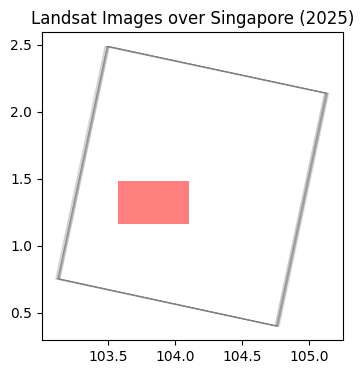

In [21]:
# plot geometry of the first image over bbox
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
images.boundary.plot(ax=ax, color="grey", lw = 0.5, alpha = 0.25)
bbox_geom.plot(ax=ax, alpha=0.5, color='red')
ax.set_title("Landsat Images over Singapore (2025)")
plt.show()

In [22]:
images['datetime']

0     2025-12-05T03:16:53.020717Z
1     2025-10-26T03:16:56.862517Z
2     2025-10-18T03:16:53.631057Z
3     2025-10-02T03:16:50.126636Z
4     2025-09-24T03:16:54.283250Z
5     2025-09-16T03:16:49.339000Z
6     2025-08-31T03:16:43.331460Z
7     2025-08-15T03:16:40.609062Z
8     2025-08-07T03:16:37.245772Z
9     2025-07-30T03:16:31.138217Z
10    2025-07-06T03:16:21.508881Z
11    2025-06-04T03:16:03.252746Z
12    2025-05-27T03:16:06.535937Z
13    2025-05-11T03:16:01.366621Z
14    2025-05-03T03:16:21.006842Z
15    2025-04-25T03:16:01.939862Z
16    2025-04-09T03:16:13.992654Z
17    2025-04-01T03:16:27.193576Z
18    2025-03-08T03:16:29.518677Z
19    2025-02-20T03:16:35.303615Z
20    2025-02-12T03:16:48.524034Z
21    2025-01-27T03:16:46.832338Z
22    2025-01-03T03:16:41.531333Z
Name: datetime, dtype: str

Text(0, 0.5, 'Cloud Cover (%)')

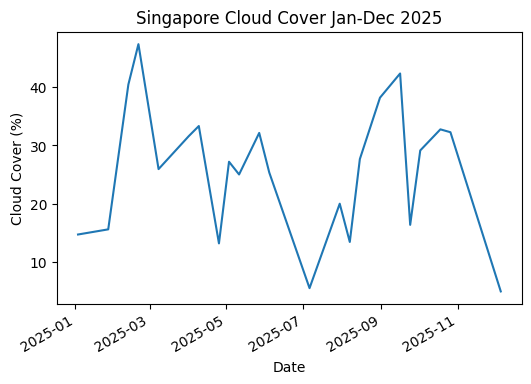

In [23]:
# fix datetime on the x axis to just show year-month on an angle
images['datetime'] = pd.to_datetime(images['datetime'])
ts = images.set_index("datetime").sort_index()["eo:cloud_cover"]
ts.plot(title="Singapore Cloud Cover Jan-Dec 2025", figsize=(6, 4))
plt.xlabel("Date")
plt.ylabel("Cloud Cover (%)")

In [24]:
import rich.table

In [25]:
# create a rich table with all bands/elements of the raster file
table = rich.table.Table("Asset Key", "Descripiption")
for asset_key, asset in low_cloud.assets.items():
    # print(f"{asset_key:<25} - {asset.title}")
    table.add_row(asset_key, asset.title)

table

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Asset Key        ┃ Descripiption                                                        ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ qa               │ Surface Temperature Quality Assessment Band                          │
│ ang              │ Angle Coefficients File                                              │
│ red              │ Red Band                                                             │
│ blue             │ Blue Band                                                            │
│ drad             │ Downwelled Radiance Band                                             │
│ emis             │ Emissivity Band                                                      │
│ emsd             │ Emissivity Standard Deviation Band                                   │
│ trad             │ Thermal Radiance Band                                                │
│ urad             │ Upwelled Radiance Band                                               │
│ atran            │ Atmospheric Transmittance Band                                       │
│ cdist            │ Cloud Distance Band                                                  │
│ green            │ Green Band                                                           │
│ nir08            │ Near Infrared Band 0.8                                               │
│ lwir11           │ Surface Temperature Band                                             │
│ swir16           │ Short-wave Infrared Band 1.6                                         │
│ swir22           │ Short-wave Infrared Band 2.2                                         │
│ coastal          │ Coastal/Aerosol Band                                                 │
│ mtl.txt          │ Product Metadata File (txt)                                          │
│ mtl.xml          │ Product Metadata File (xml)                                          │
│ mtl.json         │ Product Metadata File (json)                                         │
│ qa_pixel         │ Pixel Quality Assessment Band                                        │
│ qa_radsat        │ Radiometric Saturation and Terrain Occlusion Quality Assessment Band │
│ qa_aerosol       │ Aerosol Quality Assessment Band                                      │
│ tilejson         │ TileJSON with default rendering                                      │
│ rendered_preview │ Rendered preview                                                     │
└──────────────────┴──────────────────────────────────────────────────────────────────────┘

In [26]:
# identify bands of interest to load
bandsofinterest = ['red', 'green', 'blue', 'nir08', 'qa_pixel']

In [28]:
import xarray as xr
import rasterio.features

In [30]:
# load raster datasets based on parameters
data = odc.stac.stac_load(
    items=items,
    bands=bandsofinterest,
    bbox=bbox,
    chunks={}
)

In [32]:
da = data.to_array(dim="band").compute()

Exception: RasterioIOError('HTTP response code: 409')

In [ ]:
odc.stac.stac_load?

In [ ]:
items